In [ ]:
import open3d as o3d
import numpy as np
import os
import matplotlib.pyplot as plt
import re
import math

EXPERIMENT = "test_8_simulation2"
TARGET_VIEW_INDEX = 211  
TARGET_SURFACE = "surface1"  # Set to "" to view the full viewpoint

# Directories
SIM_DATA_DIR = f'../anr_pkg/src/viewpoints_candidate/testing_data/{EXPERIMENT}/'
PROCESSED_ACTUAL_DIR = f'../anr_pkg/src/processed_data/{EXPERIMENT}/'
EVALUATION_DIR = f'../anr_pkg/src/evaluation_result/{EXPERIMENT}/'


def default_visualization(geometries, window_name="Default Visualization", zoom=1.0):
    azimuth_deg = 45
    elevation_deg = 135
    az = math.radians(azimuth_deg)
    el = math.radians(elevation_deg)
    # spherical → cartesian (camera front vector)
    front = np.array([
        math.cos(el) * math.cos(az),
        math.cos(el) * math.sin(az),
        math.sin(el)
    ])
    # Open3D camera looks toward object
    front = -front
    lookat = geometries[0].get_center()
    up = [0, 0, -1]  # typical CAD Z-up
    o3d.visualization.draw_geometries(
        geometries,
        window_name=window_name,
        width=1024,
        height=768,
        lookat=lookat,
        up=up,
        front=front,
        zoom=zoom
    )

def apply_aoi_colors(pcd):
    """Calculates Angle of Incidence and applies the Viridis heatmap to a point cloud."""
    xyz = np.asarray(pcd.points)
    normals = np.asarray(pcd.normals)
    
    if len(normals) == 0:
        print("Warning: Point cloud has no normals to calculate AoI.")
        return pcd
        
    P = xyz
    V = -P
    V_norm = np.linalg.norm(V, axis=1, keepdims=True)
    V_normalized = V / (V_norm + 1e-6)
    
    N_norm = np.linalg.norm(normals, axis=1, keepdims=True)
    N_normalized = normals / (N_norm + 1e-6)
    
    aoi_cos = np.sum(V_normalized * N_normalized, axis=1)
    aoi_normalized = np.clip(aoi_cos, 0, 1)
    
    cmap = plt.get_cmap("viridis")
    colors = cmap(aoi_normalized)[:, :3]
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd

def create_camera_frustum(scale=20.0):
    points = [
        [0, 0, 0],
        [-scale, -scale, scale * 2],
        [scale, -scale, scale * 2],
        [scale, scale, scale * 2],
        [-scale, scale, scale * 2]
    ]
    lines = [
        [0, 1], [0, 2], [0, 3], [0, 4],
        [1, 2], [2, 3], [3, 4], [4, 1]
    ]
    colors = [[1, 0, 0] for _ in range(len(lines))] 
    frustum = o3d.geometry.LineSet()
    frustum.points = o3d.utility.Vector3dVector(points)
    frustum.lines = o3d.utility.Vector2iVector(lines)
    frustum.colors = o3d.utility.Vector3dVector(colors)
    return frustum

# --- SCRIPT START ---
import glob
if TARGET_SURFACE:
    search_target = f"viewpoint_simulated_{TARGET_VIEW_INDEX}_{TARGET_SURFACE}.pcd"
else:
    search_target = f"viewpoint_simulated_{TARGET_VIEW_INDEX}.pcd"

# Find the ML Input Feature (Perfect CAD crop) in PROCESSED_ACTUAL_DIR
filename = search_target
feature_file_path = os.path.join(PROCESSED_ACTUAL_DIR, filename)
if not os.path.exists(feature_file_path):
    matches = glob.glob(os.path.join(PROCESSED_ACTUAL_DIR, "*", search_target))
    if matches:
        feature_file_path = matches[0]
        filename = os.path.relpath(feature_file_path, PROCESSED_ACTUAL_DIR).replace('\\', '/')

# The actual real scan is ALWAYS the full viewpoint scan
actual_search_target = f"viewpoint_simulated_noise_{TARGET_VIEW_INDEX}.pcd"
actual_file_path = os.path.join(PROCESSED_ACTUAL_DIR, actual_search_target)
if not os.path.exists(actual_file_path):
    matches = glob.glob(os.path.join(PROCESSED_ACTUAL_DIR, "*", actual_search_target))
    if matches:
        actual_file_path = matches[0]
import re
match = re.search(r'viewpoint_simulated(?:_noise)?_(\d+)', filename)
view_index = int(match.group(1)) if match else 0
dirname = os.path.dirname(filename)
tf_path = os.path.join(SIM_DATA_DIR, dirname, f"viewpoint_pose_{view_index}.npy")
if not os.path.exists(tf_path):
    tf_path = os.path.join(SIM_DATA_DIR, f"viewpoint_pose_{view_index}.npy")

T_camera_object = np.eye(4)
if os.path.exists(tf_path):
    T_object_camera = np.load(tf_path)
    T_camera_object = np.linalg.inv(T_object_camera)
else:
    print(f"Warning: TF not found at {tf_path}")

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=20, origin=[0, 0, 0])
camera_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=50.0, origin=[0, 0, 0])
camera_frustum = create_camera_frustum(scale=20.0)

# ==========================================
# 1. PROCESS AND SHOW SIMULATED CAD
# ==========================================
pcd_sim = None
if TARGET_SURFACE:
    if os.path.exists(feature_file_path):
        pcd_sim = o3d.io.read_point_cloud(feature_file_path)
        # Compute normals if missing (needed for AoI)
        if not pcd_sim.has_normals():
            pcd_sim.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5.0, max_nn=30))
            pcd_sim.orient_normals_towards_camera_location(camera_location=np.array([0., 0., 0.]))
else:
    sim_file_path = os.path.join(SIM_DATA_DIR, filename)
    if os.path.exists(sim_file_path):
        pcd_sim = o3d.io.read_point_cloud(sim_file_path)

if pcd_sim is not None:
    if os.path.exists(tf_path):
        pcd_sim.transform(T_camera_object)
    
    pcd_sim = apply_aoi_colors(pcd_sim)
    
    print(f"Opening Window 1: Perfect CAD View ({TARGET_SURFACE if TARGET_SURFACE else 'Full'})")
    default_visualization(
        [pcd_sim], 
        window_name=f"PERFECT CAD - Angle of Incidence"
    )

# ==========================================
# 2. PROCESS AND SHOW ACTUAL REAL SCAN
# ==========================================
if os.path.exists(actual_file_path):
    pcd_actual = o3d.io.read_point_cloud(actual_file_path)
    
    align_tf_path = os.path.join(EVALUATION_DIR, dirname, "merge_full_transformation.npy")
    if not os.path.exists(align_tf_path):
        align_tf_path = os.path.join(EVALUATION_DIR, "merge_full_transformation.npy")
    if os.path.exists(align_tf_path):
        merge_full_transformation = np.load(align_tf_path)
        # Transform Real Scan -> CAD Frame -> Virtual Camera Frame
        T_target_to_object = np.linalg.inv(merge_full_transformation)
        T_target_to_camera = T_camera_object @ T_target_to_object
        pcd_actual.transform(T_target_to_camera)
        
        # Apply Angle of Incidence colors to the REAL scan!
        pcd_actual = apply_aoi_colors(pcd_actual)
        
        print(f"Opening Window 2: Processed Actual Scan View {view_index}")
        default_visualization(
            # [pcd_actual, camera_frame, camera_frustum], 
            [pcd_actual, world_frame], 
            window_name=f"PROCESSED ACTUAL SCAN (View {view_index}) - Angle of Incidence"
        )
        
else:
    print(f"Warning: Processed actual point cloud not found at {actual_file_path}")

# 🟡 Yellow (1.0): The surface is facing perfectly directly at the camera lens. The Angle of Incidence is 0°
# 🟢 Teal / Green (~0.5): The surface is tilted relative to the camera lens. The Angle of Incidence is roughly 60°
# 🟣 Dark Purple (0.0): The surface is facing completely away from the camera, is at a sharp grazing angle (90° sideways), or the normal is pointing inwards.


Opening Window 1: Perfect CAD View (surface1)
Opening Window 2: Processed Actual Scan View 211


In [12]:
# MAIN TRAINING BLOCK #

import os
import sys
import datetime
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
import torch.nn.functional as F
import importlib
import open3d as o3d

# ==========================================
# 1. PATH & DEVICE CONFIGURATION
# ==========================================
BASE_DIR = os.getcwd()
sys.path.append(os.path.join(BASE_DIR, 'models'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project Root: {BASE_DIR}")
print(f"Using Device: {device}")

# ==========================================
# 2. REGRESSION DATASET CLASS
# ==========================================
class ChamferRegressionDataset(Dataset):
    def __init__(self, metadata, pcd_dir, indices, num_points=1024, is_training=False):
        self.metadata = metadata.iloc[indices].reset_index(drop=True)
        self.pcd_dir = pcd_dir
        self.num_points = num_points
        self.is_training = is_training
        self.cache = {}

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        if idx in self.cache:
            points, chamfer_out = self.cache[idx]
        else:
            filename = self.metadata.iloc[idx, 0]
            chamfer = self.metadata.iloc[idx, 3]

            file_path = os.path.join(self.pcd_dir, filename)
            pcd = o3d.io.read_point_cloud(file_path)

            if len(pcd.points) == 0:
                print(f"Warning: File {file_path} is empty or not found.")
                return

            # FPS sampling
            if len(pcd.points) > self.num_points:
                pcd = pcd.farthest_point_down_sample(self.num_points)

            xyz = np.asarray(pcd.points)
            normals = np.asarray(pcd.normals)
            has_normals = len(normals) > 0
            import re
            match = re.search(r'viewpoint_simulated(?:_noise)?_(\d+)', filename)
            view_index = int(match.group(1)) if match else 0
            
            dirname = os.path.dirname(filename)
            tf_path = os.path.join(self.pcd_dir.replace('processed_data', 'viewpoints_candidate/testing_data'), dirname, f"viewpoint_pose_{view_index}.npy")
            
            if os.path.exists(tf_path):
                T_object_camera = np.load(tf_path)
                T_camera_object = np.linalg.inv(T_object_camera)
                xyz_homogeneous = np.hstack((xyz, np.ones((xyz.shape[0], 1))))
                xyz = (T_camera_object @ xyz_homogeneous.T).T[:, :3]
                R_camera_object = T_camera_object[:3, :3]
                if has_normals:
                    normals = (R_camera_object @ normals.T).T
                else:
                    # Estimate normals in camera space
                    pcd_temp = o3d.geometry.PointCloud()
                    pcd_temp.points = o3d.utility.Vector3dVector(xyz)
                    pcd_temp.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5.0, max_nn=30))
                    pcd_temp.orient_normals_towards_camera_location(camera_location=np.array([0., 0., 0.]))
                    normals = np.asarray(pcd_temp.normals)
            else:
                print(f"Warning: TF not found at {tf_path}. Using untransformed data.")
                if not has_normals:
                    pcd_temp = o3d.geometry.PointCloud()
                    pcd_temp.points = o3d.utility.Vector3dVector(xyz)
                    pcd_temp.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5.0, max_nn=30))
                    pcd_temp.orient_normals_towards_camera_location(camera_location=np.array([0., 0., 0.]))
                    normals = np.asarray(pcd_temp.normals)
            # --- 2. Calculate Angle of Incidence (AoI) ---
            P = xyz
            V = -P
            V_norm = np.linalg.norm(V, axis=1, keepdims=True)
            V_normalized = V / (V_norm + 1e-6)
            
            N_norm = np.linalg.norm(normals, axis=1, keepdims=True)
            N_normalized = normals / (N_norm + 1e-6)
            
            aoi_cos = np.sum(V_normalized * N_normalized, axis=1, keepdims=True)
            
            # --- 3. Concatenate to [N, 7] ---
            points = np.hstack((xyz, normals, aoi_cos))

            # Spatial Normalization 
            points[:, 0:3] -= np.mean(points[:, 0:3], axis=0)
            scale = np.max(np.linalg.norm(points[:, 0:3], axis=1))
            if scale > 0:
                points[:, 0:3] /= scale

            # Padding if necessary
            if len(points) < self.num_points:
                idx_sample = np.random.choice(len(points), self.num_points, replace=True)
                points = points[idx_sample]

            chamfer_out = chamfer
            self.cache[idx] = (points, chamfer_out)

        points_np = points.copy()
        if self.is_training:
            import provider
            points_np = np.expand_dims(points_np, axis=0)
            # Jitter only XYZ coordinates (channels 0, 1, 2) to prevent corrupting Normals/AoI
            points_np[:, :, 0:3] = provider.jitter_point_cloud(points_np[:, :, 0:3], sigma=0.01, clip=0.05)
            # points_np = provider.rotate_perturbation_point_cloud_with_normal(points_np, angle_sigma=0.06, angle_clip=0.08726)
            points_np = points_np.squeeze(0)

        points_tensor = torch.tensor(points_np, dtype=torch.float32).transpose(1, 0)
        target_tensor = torch.tensor([chamfer_out], dtype=torch.float32)

        return points_tensor, target_tensor
# ==========================================
# 3. TRAINING LOOP
# ==========================================
def run_training(model, train_loader, val_loader, optimizer, scheduler, criterion, epochs, 
                 y_mean=0.0, y_std=1.0, use_norm=True, use_loss_weighting=False, patience=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for points, target in train_loader:
            points, target = points.to(device), target.to(device)
            optimizer.zero_grad()
            pred, trans_feat = model(points)
            
            loss = criterion(pred, target, trans_feat)

            
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        if scheduler is not None:
            pass
            # scheduler.step()
            # if epoch % 50 == 0:
            #     print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
                
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for points, target in val_loader:
                points, target = points.to(device), target.to(device)
                # pred, trans_feat = model(points) # PointNet
                pred, trans_feat = model(points)
                v_loss = criterion(pred, target, trans_feat)
                val_loss += v_loss.item()

        avg_val_loss = val_loss / len(val_loader)
        if scheduler is not None:
            scheduler.step(avg_val_loss)
            if epoch % 10 == 0:
                print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
            
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss (MSE): {avg_train_loss:.2f} | Val Loss (MSE): {avg_val_loss:.2f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_regression_model.pth')
            print(f">>> New Best Model Saved: {avg_val_loss:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered! No improvement for {patience} epochs.")
                break

    return history

# ==========================================
# 4. MAIN
# ==========================================
BATCH_SIZE = 32
LR = 5e-4
EPOCHS = 1000
INPUT_POINT_CLOUD = 2500
PATIENCE = 50

MODEL = 'pointnet2_regression'
EXPERIMENT = "test_8_simulation2"
TARGET_SURFACE_FILTER = "surface0" # Set to 'surface0', 'surface1', or None for all

METADATA_PATH = f'../anr_pkg/src/processed_data/{EXPERIMENT}/metadata.csv'
PCD_DATA_DIR = f'../anr_pkg/src/processed_data/{EXPERIMENT}/'

metadata = pd.read_csv(METADATA_PATH)

# --- MIXTURE OF EXPERTS WORKAROUND ---
# Filter the dataset directly in Pandas without moving any files on disk!
if TARGET_SURFACE_FILTER:
    metadata = metadata[metadata['filename'].str.contains(TARGET_SURFACE_FILTER)].reset_index(drop=True)
    print(f"Filtered dataset strictly to {TARGET_SURFACE_FILTER}. Remaining samples: {len(metadata)}")
# -------------------------------------

# train_workpieces = ["TH0011AV", "TH0012AV", "TH0021AV", "TH0032AV"]
train_workpieces = ["TH0011AV", "TH0012AV", "TH0021AV", "TH0032AV", "TH0041AV", "TH0042AV", "TH0051AV", "TH0052AV", "TH0061AV", "TH0062AV", "TH0071AV", "TH0072AV"]
test_workpieces = ["TH0022AV", "TH0031AV"]

train_val_indices = metadata.index[metadata['filename'].apply(lambda x: any(wp in x for wp in train_workpieces))].tolist()
test_indices = metadata.index[metadata['filename'].apply(lambda x: any(wp in x for wp in test_workpieces))].tolist()

np.random.seed(42)
np.random.shuffle(train_val_indices)

split_idx = int(0.8 * len(train_val_indices))
train_indices = train_val_indices[:split_idx]
val_indices = train_val_indices[split_idx:]

# calculate target stats
y_mean = metadata.iloc[train_indices, 3].mean()
y_std = metadata.iloc[train_indices, 3].std()
print(f"Target Mean: {y_mean:.4f} | Target Std: {y_std:.4f}")

# ----------------------------------------------------
# NEW: Stratified Sampling (Weighted Random Sampler)
# ----------------------------------------------------
y_train = metadata.iloc[train_indices, 3].values

# 1. Create histogram bins of the dataset to find frequencies (10 bins)
counts, bins = np.histogram(y_train, bins=10)

# 2. Find which bin each sample belongs to
bin_inds = np.digitize(y_train, bins) - 1
bin_inds = np.clip(bin_inds, 0, len(counts) - 1)

# 3. Calculate weights inversely proportional to frequencies
class_weights = 1.0 / (counts + 1e-5)

# 4. Assign weight to each sample based on its bin
sample_weights = class_weights[bin_inds]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights), 
    num_samples=len(sample_weights), 
    replacement=True
)
# ----------------------------------------------------

# datasets
train_ds = ChamferRegressionDataset(metadata, PCD_DATA_DIR, train_indices, num_points=INPUT_POINT_CLOUD, is_training=True)
val_ds   = ChamferRegressionDataset(metadata, PCD_DATA_DIR, val_indices, num_points=INPUT_POINT_CLOUD, is_training=False)
test_ds   = ChamferRegressionDataset(metadata, PCD_DATA_DIR, test_indices, num_points=INPUT_POINT_CLOUD, is_training=False)

# Note: When using a sampler, shuffle must be False
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler) #sampler=sampler (weightedrandom) / shuffle=True (random)

val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
reg_module = importlib.import_module(MODEL)
importlib.reload(reg_module) # Force Jupyter to reload the file if you made edits!
model = reg_module.get_model(normal_channel=True).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n--- MODEL LOADED SUCCESSFULLY ---")
print(f"Architecture: {MODEL}")
print(f"Trainable Parameters: {total_params:,}")
print(f"---------------------------------\n")
criterion = reg_module.get_loss().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = None


print(f"Training on: {len(train_ds)} | Validation: {len(val_ds)} | Testing: {len(test_ds)}")



# sys.stdout = sys.__stdout__
# log_file.close()

Project Root: c:\Users\Alvan\Documents\Alvan\Data\Code\Python\Main\pointnet_pytorch_reflective
Using Device: cuda
Filtered dataset strictly to surface0. Remaining samples: 5616
Target Mean: 2.0502 | Target Std: 0.0887

--- MODEL LOADED SUCCESSFULLY ---
Architecture: pointnet2_regression
Trainable Parameters: 1,465,921
---------------------------------

Training on: 4147 | Validation: 1037 | Testing: 432


In [7]:
# # Redirect all print statements to a text file
# timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# filename = f"log/log_{timestamp}.txt"
# os.makedirs("log", exist_ok=True)
# log_file = open(filename, "w")structural understanding up the hierarchy.
# sys.stdout = log_file

train_history = run_training(
    model, train_loader, val_loader, optimizer, scheduler, criterion, EPOCHS, patience=PATIENCE,
)

# sys.stdout = sys.__stdout__
# log_file.close()

Epoch 1/1000 | Train Loss (MSE): 0.45 | Val Loss (MSE): 0.08
>>> New Best Model Saved: 0.0772
Epoch 2/1000 | Train Loss (MSE): 0.03 | Val Loss (MSE): 0.01
>>> New Best Model Saved: 0.0127
Epoch 3/1000 | Train Loss (MSE): 0.02 | Val Loss (MSE): 0.02
Epoch 4/1000 | Train Loss (MSE): 0.02 | Val Loss (MSE): 0.01
Epoch 5/1000 | Train Loss (MSE): 0.02 | Val Loss (MSE): 0.01
>>> New Best Model Saved: 0.0120
Epoch 6/1000 | Train Loss (MSE): 0.02 | Val Loss (MSE): 0.02
Epoch 7/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.01
Epoch 8/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.02
Epoch 9/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.02
Epoch 10/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.01
>>> New Best Model Saved: 0.0097
Epoch 11/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.01
Epoch 12/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.01
Epoch 13/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.01
Epoch 14/1000 | Train Loss (MSE): 0.01 | Val Loss (MSE): 0.01
Epoch 15/

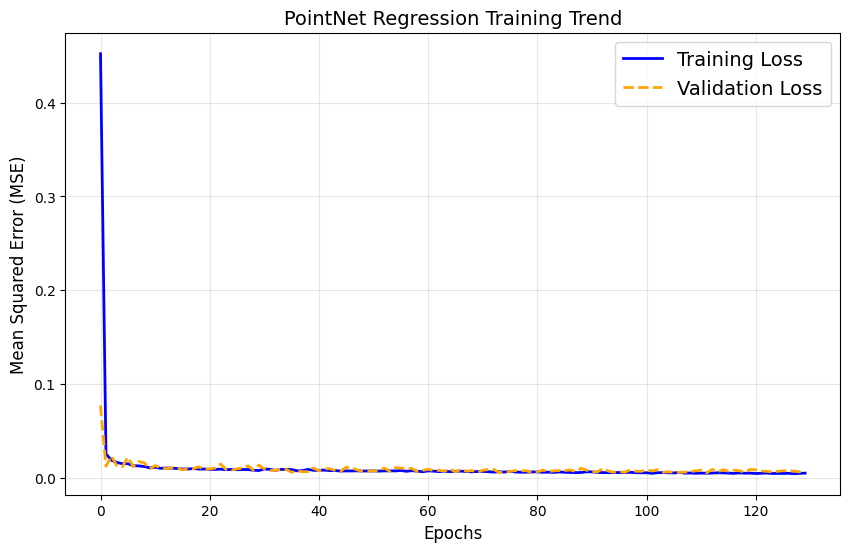

In [8]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    plt.figure(figsize=(10, 6))
    
    # Plot Training Loss
    plt.plot(history['train_loss'], label='Training Loss', color='blue', linewidth=2)
    
    # Plot Validation Loss
    plt.plot(history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
    
    plt.title('PointNet Regression Training Trend', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)

    # plt.ylim(0, 1.5)
    # plt.xlim(0, 500)
    
    # Save the plot as an image for your thesis report
    plt.savefig('training_trend.png')
    plt.show()

# Generate the plot
plot_learning_curves(train_history)

In [6]:
# Inference

import torch
import importlib

INDEX = 10  # Change this index to test different samples from the dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
reg_module = importlib.import_module(MODEL)
importlib.reload(reg_module) # Force Jupyter to reload the file if you made edits!
model = reg_module.get_model(normal_channel=True).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n--- MODEL LOADED SUCCESSFULLY ---")
print(f"Architecture: {MODEL}")
print(f"Trainable Parameters: {total_params:,}")
print(f"---------------------------------\n")

model.load_state_dict(torch.load('best_regression_model.pth'))
model.eval()

points, target = test_ds[INDEX]   # Switch to use test_ds

points = points.unsqueeze(0).to(device)

with torch.no_grad():
    pred, trans_feat = model(points)

pred_norm = pred.squeeze(0).cpu().numpy()[0]

pred_final = pred_norm

target_final = target.numpy()[0]
print("Example")
print("Predicted CD (Original Units): ", pred_final)
print("Ground Truth CD (Original Units): ", target_final)



--- MODEL LOADED SUCCESSFULLY ---
Architecture: pointnet2_regression
Trainable Parameters: 1,465,921
---------------------------------

Example
Predicted CD (Original Units):  2.1722362
Ground Truth CD (Original Units):  2.0111012


In [7]:
# INFERENCE CSV #

import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
import importlib

def generate_inference_csv(model_path, metadata_path, pcd_dir, device):
    print(f"Loading metadata from {metadata_path}...")
    metadata = pd.read_csv(metadata_path)
    
    # Create indices for ALL rows in the metadata
    all_indices = list(range(len(metadata)))
    
    # Initialize the dataset
    ds = ChamferRegressionDataset(
        metadata, pcd_dir, all_indices, num_points=5000,
        is_training=False, 
    )
    # Batch size of 16 and multiprocessing to speed up inference
    loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
    
    # Load model architecture and weights
    print(f"Loading model weights from {model_path}...")
    reg_module = importlib.import_module('pointnet2_regression')
    model = reg_module.get_model(normal_channel=True).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    results = []
    
    print(f"Running inference on {len(all_indices)} samples...")
    with torch.no_grad():
        for i, (points, target) in enumerate(loader):
            points = points.to(device)
            pred, trans_feat = model(points)
            
            for b in range(points.size(0)):
                pred_val = pred[b].item()
                gt_val = target[b].item()
                error = abs(gt_val - pred_val)
                
                global_idx = all_indices[i * 16 + b]
                filename = metadata.iloc[global_idx]['filename']
                
                results.append({
                    'Original_Index': global_idx,
                    'Filename': filename,
                    'Split': 'Testing',
                    'GroundTruth_CD': gt_val,
                    'Predicted_CD': pred_val,
                    'Error': error
                })

    # Create DataFrame and Save
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by="Original_Index", ascending=True)
    
    save_path = "inference_results.csv"
    df_results.to_csv(save_path, index=False)
    print(f"Results saved to {save_path}")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # EDIT THESE VARIABLES FOR NEW DATASETS
    MODEL_WEIGHTS = "best_regression_model.pth"
    
    # Example for running inference on an entirely new dataset:
    INFERENCE_EXPERIMENT = "test_7_simulation"
    INFERENCE_METADATA_PATH = f'../anr_pkg/src/processed_data/{INFERENCE_EXPERIMENT}/metadata.csv'
    INFERENCE_PCD_DIR = f'../anr_pkg/src/processed_data/{INFERENCE_EXPERIMENT}/'
    
    generate_inference_csv(
        model_path=MODEL_WEIGHTS,
        metadata_path=INFERENCE_METADATA_PATH,
        pcd_dir=INFERENCE_PCD_DIR,
        device=device
    )


Loading metadata from ../anr_pkg/src/processed_data/test_7_simulation/metadata.csv...
Loading model weights from best_regression_model.pth...
Running inference on 2592 samples...
Results saved to inference_results.csv


In [16]:
df = pd.read_csv("inference_results.csv")

# Filter to only look at TH0021AV
test_workpiece = df[df['filename'].str.contains("TH0032AV")]

# Now you can calculate your MAE or plot graphs just for this unseen workpiece!
print(test_workpiece['Error'].mean())


0.0903558869052816


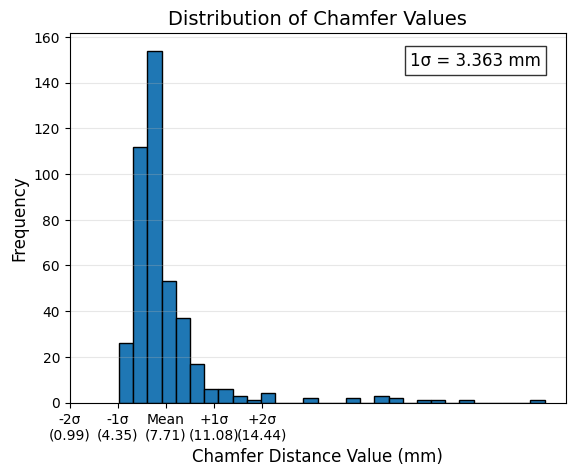

In [54]:
# HISTOGRAM ANALYSIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TARGET_WORKPIECE = f""
# TARGET_SURFACE = f"surface1"


# df = pd.read_csv(METADATA_PATH)

CSV_PATH = f"../anr_pkg/src/processed_data/training_second_square_flange/metadata.csv"
df = pd.read_csv(CSV_PATH)


# df = df[df['filename'].str.contains(TARGET_WORKPIECE) & df['filename'].str.contains(TARGET_SURFACE)]
# df = df[df['filename'].str.contains(TARGET_SURFACE)]

# Define your bins and plot
plt.hist(df['chamfer_value'], bins=30, edgecolor='black')

# Calculate Mean and Sigma (Standard Deviation)
mean_val = df['chamfer_value'].mean()
std_val = df['chamfer_value'].std()

# Create ticks for Mean, +- 1 Sigma, +- 2 Sigma
ticks = [
    mean_val - 2*std_val,
    mean_val - std_val,
    mean_val,
    mean_val + std_val,
    mean_val + 2*std_val
]

# Format the tick labels to look nice (e.g., 'Mean\n(2.10)')
tick_labels = [
    f'-2σ\n({ticks[0]:.2f})',
    f'-1σ\n({ticks[1]:.2f})',
    f'Mean\n({ticks[2]:.2f})',
    f'+1σ\n({ticks[3]:.2f})',
    f'+2σ\n({ticks[4]:.2f})'
]

plt.xticks(ticks, tick_labels)

plt.xlabel('Chamfer Distance Value (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Chamfer Values', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Draw vertical lines for the sigmas to make it visually clear
# plt.axvline(mean_val, color='red', linestyle='solid', linewidth=2, label='Mean')
# plt.axvline(mean_val - std_val, color='red', linestyle='dashed', linewidth=1.5, label='±1 Sigma')
# plt.axvline(mean_val + std_val, color='red', linestyle='dashed', linewidth=1.5)
# plt.axvline(mean_val - 2*std_val, color='red', linestyle='dotted', linewidth=1.5, label='±2 Sigma')
# plt.axvline(mean_val + 2*std_val, color='red', linestyle='dotted', linewidth=1.5)
# plt.legend()

plt.text(0.95, 0.95, f'1σ = {std_val:.3f} mm', horizontalalignment='right', verticalalignment='top', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'), fontsize=12)
plt.show()


--- TEST DATA PERFORMANCE (2592 samples) ---
Mean Absolute Error (MAE): 0.09 mm
Root Mean Squared Error (RMSE): 0.11 mm
R-Squared (R²): 0.26
Max Error: 0.44 mm
Equation: y = 0.40x + 1.24


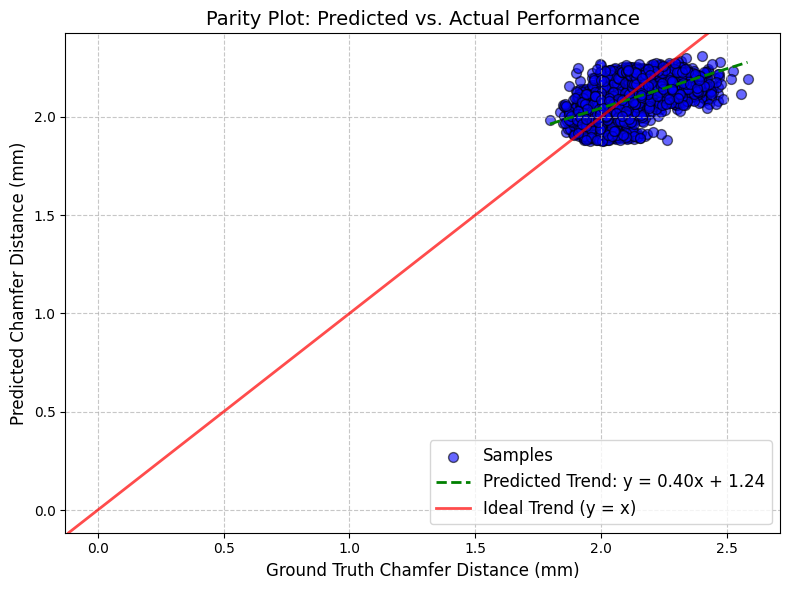

In [32]:
# MODEL RESULT ANALYTICS #

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error

# ── Configuration ────────────────────────────────────────────────────────────
# Set to True  → analyse Test split only (standard performance reporting)
# Set to False → analyse ALL splits (e.g. evaluating a brand-new workpiece)
FILTER_TO_TESTING = True

# Load full CSV (all splits, all Error_Class labels intact)
df_full = pd.read_csv('./inference_results.csv')

# Apply filter based on flag — one place to change, no commenting needed
if FILTER_TO_TESTING:
    df = df_full[df_full['Split'] == 'Testing'].copy()
    print(f"--- TEST DATA PERFORMANCE ({len(df)} samples) ---")
else:
    df = df_full.copy()
    print(f"--- ALL DATA PERFORMANCE ({len(df)} samples, all splits) ---")

# Extract values for readability
y_true = df['GroundTruth_CD']
y_pred = df['Predicted_CD']

# Calculate Performance Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
max_err = max_error(y_true, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} mm")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} mm")
print(f"R-Squared (R\u00b2): {r2:.2f}")
print(f"Max Error: {max_err:.2f} mm")

# Calculate Actual Trendline
z = np.polyfit(y_true, y_pred, 1)
p = np.poly1d(z)
slope = z[0]
intercept = z[1]

print(f"Equation: y = {slope:.2f}x + {intercept:.2f}")


# Parity Plot
fig1, ax1 = plt.subplots(figsize=(8, 6))

# Scatter plot
ax1.scatter(y_true, y_pred, alpha=0.6, color='blue', edgecolor='k', s=50, label='Samples')

# Trendline (sorted to prevent scribbling)
x_sorted = np.sort(y_true)
ax1.plot(x_sorted, p(x_sorted), "g--", linewidth=2,
         label=f'Predicted Trend: y = {slope:.2f}x + {intercept:.2f}')

# Ideal line (y=x)
ax1.axline((0, 0), slope=1, color='r', linewidth=2, alpha=0.7, label='Ideal Trend (y = x)')

ax1.set_xlabel('Ground Truth Chamfer Distance (mm)', fontsize=12)
ax1.set_ylabel('Predicted Chamfer Distance (mm)', fontsize=12)
ax1.set_title('Parity Plot: Predicted vs. Actual Performance', fontsize=14)
ax1.legend(loc='lower right', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
# ax1.set_xlim([0, 40])
# ax1.set_ylim([0, 40])

plt.tight_layout()
# plt.savefig('parity_plot_test.png', dpi=300)
plt.show()

Class boundaries computed from: Test split (74 samples)

--- Error Analysis per Class ---
    Error_Class  Count  MAE (mm)  Bias (mm)  RMSE (mm)
0    5.9 to 9.7   43.0  0.934983  -0.351171   1.203979
1   9.7 to 13.5   24.0  1.743773  -1.532357   2.076998
2  13.5 to 17.3    5.0  3.383593  -1.399487   3.589687
3  17.3 to 21.1    2.0  4.326055  -4.326055   5.499094


C:\Users\Alvan\AppData\Local\Temp\ipykernel_124684\2869867641.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
C:\Users\Alvan\AppData\Local\Temp\ipykernel_124684\2869867641.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_analysis, x='Error_Class', y='RMSE (mm)', palette='coolwarm')
C:\Users\Alvan\AppData\Local\Temp\ipykernel_124684\2869867641.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fals

Text(0.5, 0, 'Ground Truth Chamfer Distance Class (mm)')

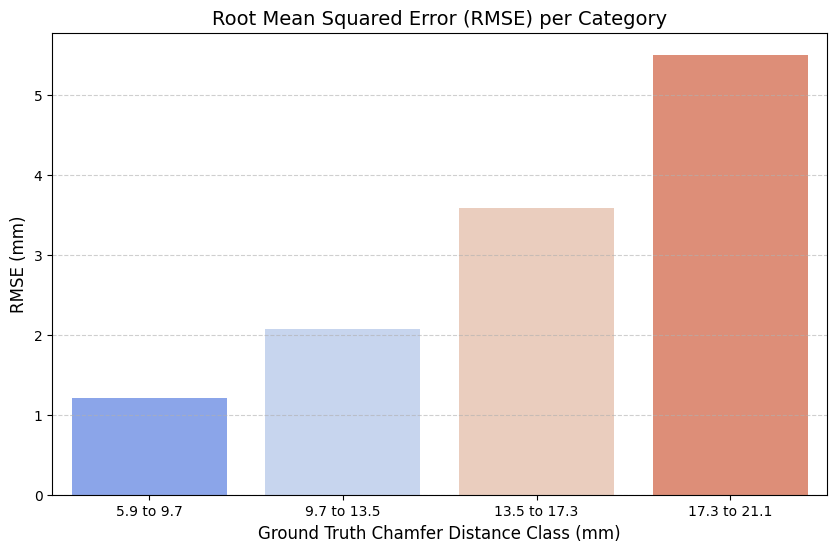

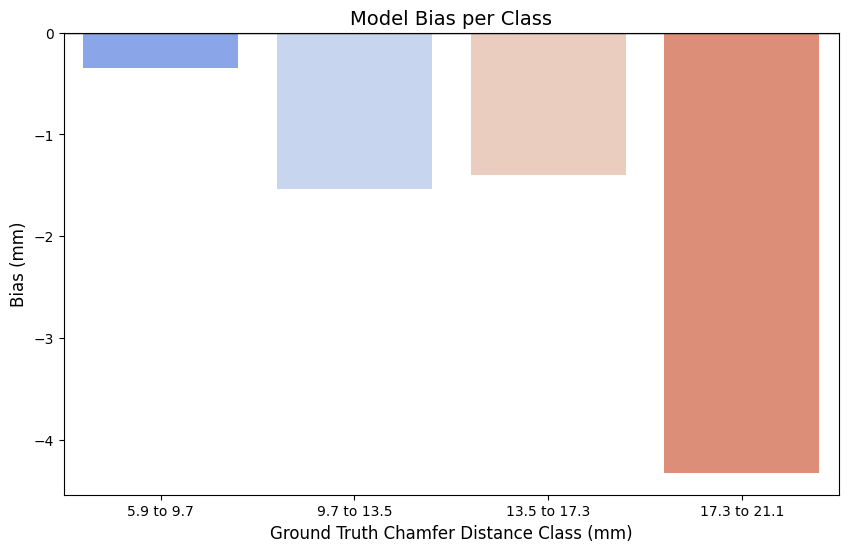

In [19]:
# CLASS-BASED ERROR ANALYSIS #

# Class boundaries are computed from the reference set that matches
# the evaluation scenario (controlled by FILTER_TO_TESTING above):
#
#   FILTER_TO_TESTING = True  → bins from Test split only
#                               (evaluating model on its own trained dataset)
#   FILTER_TO_TESTING = False → bins from ALL data
#                               (evaluating on a completely new workpiece)

# Pick the reference set for computing bin boundaries
if FILTER_TO_TESTING:
    ref_df = df_full[df_full['Split'] == 'Testing']
    ref_label = f"Test split ({len(ref_df)} samples)"
else:
    ref_df = df_full
    ref_label = f"all data ({len(ref_df)} samples)"

print(f"Class boundaries computed from: {ref_label}")

# Compute equal-width bins from the reference set
_, bins = pd.cut(ref_df['GroundTruth_CD'], bins=4, retbins=True)
labels = [f"{bins[i]:.1f} to {bins[i+1]:.1f}" for i in range(len(bins) - 1)]

# Apply those bins to the active dataset (df, set by FILTER_TO_TESTING above)
target_df = df.copy()
target_df['Error_Class'] = pd.cut(target_df['GroundTruth_CD'], bins=bins, labels=labels)

# 1. Calculate metrics per class
class_analysis = (
    target_df.groupby('Error_Class', observed=True)
    .apply(lambda x: pd.Series({
        'Count': len(x),
        'MAE (mm)': (x['Predicted_CD'] - x['GroundTruth_CD']).abs().mean(),
        'Bias (mm)': (x['Predicted_CD'] - x['GroundTruth_CD']).mean(),
        'RMSE (mm)': np.sqrt(mean_squared_error(x['GroundTruth_CD'], x['Predicted_CD']))
    }))
    .reset_index()
)

print("\n--- Error Analysis per Class ---")
print(class_analysis)

# 2. Visualization: RMSE per Class
plt.figure(figsize=(10, 6))
sns.barplot(data=class_analysis, x='Error_Class', y='RMSE (mm)', palette='coolwarm')
plt.title('Root Mean Squared Error (RMSE) per Category', fontsize=14)
plt.ylabel('RMSE (mm)', fontsize=12)
plt.xlabel('Ground Truth Chamfer Distance Class (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.savefig('mae_per_class.png')

# 3. Visualization: Bias Analysis (Crucial for Thesis)
# Shows if the model consistently under-predicts high errors
plt.figure(figsize=(10, 6))
sns.barplot(data=class_analysis, x='Error_Class', y='Bias (mm)', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.title('Model Bias per Class', fontsize=14)
plt.ylabel('Bias (mm)', fontsize=12)
plt.xlabel('Ground Truth Chamfer Distance Class (mm)', fontsize=12)
# plt.savefig('bias_per_class.png')

In [20]:
# REWRITE CSV #

# Controlled by FILTER_TO_TESTING (set in MODEL RESULT ANALYTICS above):
#
#   FILTER_TO_TESTING = True  → bins from Test split only;
#                               Training & Validation rows → NA explicitly
#   FILTER_TO_TESTING = False → bins from all data;
#                               every row gets its own class value

import pandas as pd
import numpy as np

rewrite_path = './inference_results.csv'
df_rewrite = pd.read_csv(rewrite_path)

# Pick reference set for bin boundaries
if FILTER_TO_TESTING:
    ref_rw = df_rewrite[df_rewrite['Split'] == 'Testing']
    ref_rw_label = f"Test split ({len(ref_rw)} samples)"
else:
    ref_rw = df_rewrite
    ref_rw_label = f"all data ({len(ref_rw)} samples)"

print(f"Computing Error_Class bins from: {ref_rw_label}")

# Compute equal-width bins from the reference set
_, bins = pd.cut(ref_rw['GroundTruth_CD'], bins=4, retbins=True)

# Slightly extend edges so min/max values are always included
bins[0]  -= 1e-6
bins[-1] += 1e-6

# Classify ALL rows using those bins first
df_rewrite['Error_Class'] = pd.cut(
    df_rewrite['GroundTruth_CD'], bins=bins, labels=[0, 1, 2, 3]
).astype('Int64')   # nullable integer (supports NA)

# When using Test-only bins, explicitly set non-Testing rows to NA
if FILTER_TO_TESTING:
    mask_non_test = df_rewrite['Split'] != 'Testing'
    df_rewrite.loc[mask_non_test, 'Error_Class'] = pd.NA
    print(f"Set {mask_non_test.sum()} Training/Validation rows to NA.")

# Save back to CSV
df_rewrite.to_csv(rewrite_path, index=False)

print(f"\nCSV rewritten: {rewrite_path}")
print(df_rewrite[['Original_Index', 'Split', 'GroundTruth_CD', 'Error', 'Error_Class']].head(20))

Computing Error_Class bins from: Test split (74 samples)
Set 418 Training/Validation rows to NA.

CSV rewritten: ./inference_results.csv
    Original_Index       Split  GroundTruth_CD     Error  Error_Class
0                0    Training       24.420240  3.275452         <NA>
1                1  Validation       18.962309  2.534437         <NA>
2                2    Training       17.500479  1.875418         <NA>
3                3    Training       21.493956  3.967686         <NA>
4                4  Validation       10.858139  1.559845         <NA>
5                5    Training        8.574903  0.070834         <NA>
6                6    Training        7.556761  0.443357         <NA>
7                7    Training        7.170491  0.674457         <NA>
8                8  Validation        8.064585  0.104363         <NA>
9                9    Training        9.183876  0.765237         <NA>
10              10    Training       14.329355  0.085397         <NA>
11              11    T

In [23]:
# Cell 8
# ==========================================
# PAIRWISE POINT CLOUD SIMILARITY ANALYSIS
# ==========================================
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 1. SETUP MODEL AND DATA
# ==========================================
# Create a unified dataset containing everything (both train and val data)
full_indices = np.arange(len(metadata))
full_ds = ChamferRegressionDataset(metadata, PCD_DATA_DIR, full_indices, num_points=INPUT_POINT_CLOUD, is_training=False)

# If you want to run it on every single file, change this to: NUM_SAMPLES = len(full_ds)
# WARNING: If your dataset has 2,000 files, this takes ~2,000,000 calculations and could take hours!
NUM_SAMPLES = len(train_ds) + len(val_ds) + len(test_ds) 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Loading {NUM_SAMPLES} samples from the FULL dataset for Pairwise Analysis...")
subset_indices = range(min(NUM_SAMPLES, len(full_ds)))
pcds = []
targets = []
for idx in subset_indices:
    # Get point cloud and target from the full dataset
    pts, targ = full_ds[idx]
    
    # Transpose to [N, 6] and take top 3 for XYZ coordinates
    xyz = pts.T[:, :3].to(device) 
    pcds.append(xyz)
    
    # Unnormalize target to get raw values if needed
    t_val = targ.item()
    targets.append(t_val)
pcds = torch.stack(pcds) 
targets = np.array(targets)

# ==========================================
# 2. COMPUTE SIMILARITY MATRICES
# ==========================================
def compute_pairwise_chamfer(pcds):
    N = len(pcds)
    geom_dist_matrix = np.zeros((N, N))
    
    # Using a loop to prevent GPU Out Of Memory
    for i in tqdm(range(N), desc="Computing PCD Similarity Matrix"):
        for j in range(i+1, N): # Only compute upper triangle to save time
            # Calculate Geometric Chamfer Distance between PCD i and PCD j
            dist_ij = torch.cdist(pcds[i].unsqueeze(0), pcds[j].unsqueeze(0)).squeeze(0) # [NumPts, NumPts]
            
            # Sum of mean absolute shortest path distances
            cd = (dist_ij.min(dim=1)[0].mean() + dist_ij.min(dim=0)[0].mean()).item()
            
            geom_dist_matrix[i, j] = cd
            geom_dist_matrix[j, i] = cd
            
    return geom_dist_matrix

geom_dist_matrix = compute_pairwise_chamfer(pcds)

# Measure Target Difference Matrix
# How far apart are the actual ground truth scalar chamfer values?
target_diff_matrix = np.abs(targets[:, None] - targets[None, :])

Loading 492 samples from the FULL dataset for Pairwise Analysis...


KeyboardInterrupt: 

CSV file has been saved as 'pairwise_similarity_matrix.csv'


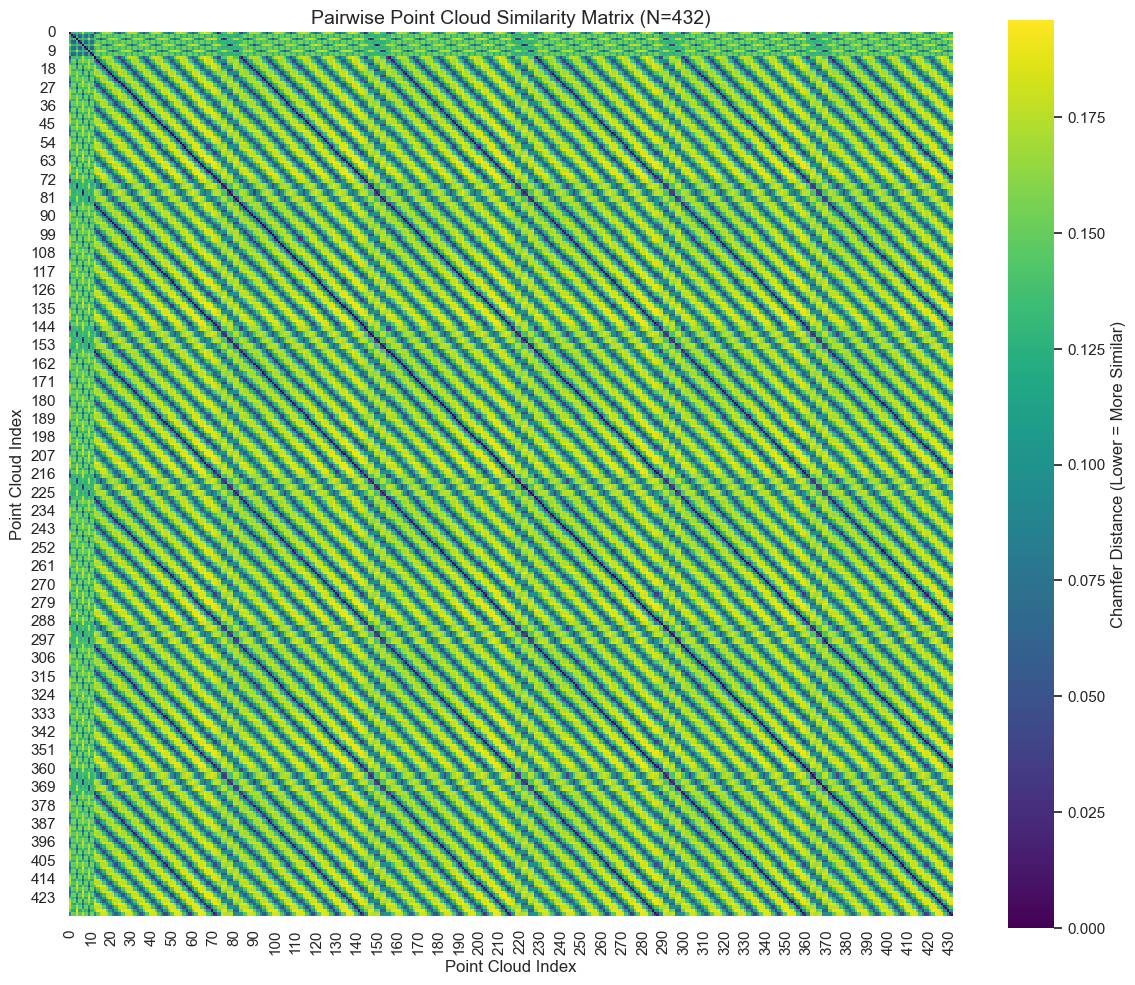

Analysis Complete!


In [52]:
# CSV

# Create labels for the rows and columns
labels = [f"PCD_{i}" for i in range(NUM_SAMPLES)]

# Convert the distance matrix to a DataFrame
df_similarity = pd.DataFrame(geom_dist_matrix, index=labels, columns=labels)

# Export to CSV
df_similarity.to_csv('pairwise_similarity_matrix.csv')

print("CSV file has been saved as 'pairwise_similarity_matrix.csv'")


# HEATMAP VISUALIZATION (NxN TABLE)
plt.figure(figsize=(12, 10))

# Create the heatmap using Seaborn
# 'viridis_r' or 'magma_r' are good for distance (smaller values = brighter/more similar)
sns.heatmap(geom_dist_matrix, 
            annot=False,      # Set to True if NUM_SAMPLES is very small (e.g., < 15) to see digits
            cmap='viridis', 
            square=True, 
            cbar_kws={'label': 'Chamfer Distance (Lower = More Similar)'})

plt.title(f"Pairwise Point Cloud Similarity Matrix (N={NUM_SAMPLES})", fontsize=14)
plt.xlabel("Point Cloud Index", fontsize=12)
plt.ylabel("Point Cloud Index", fontsize=12)

plt.tight_layout()
plt.show()

print("Analysis Complete!")

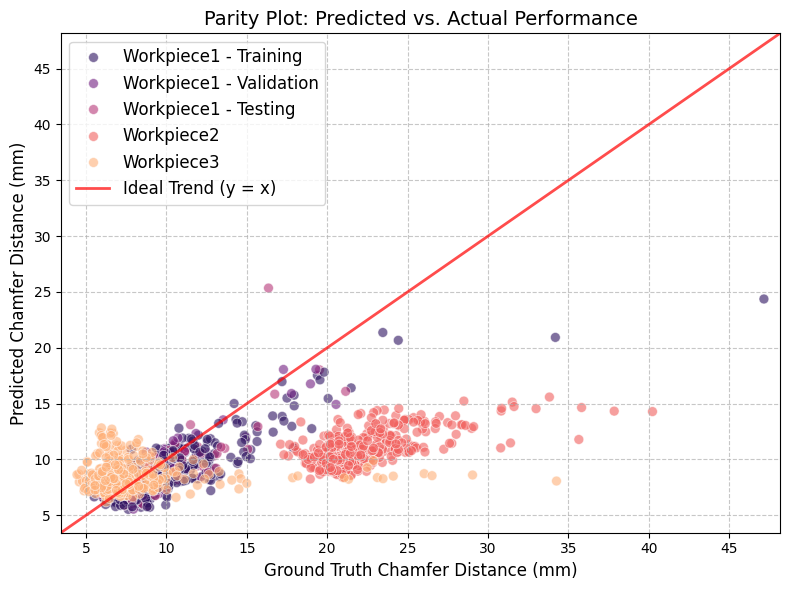

In [63]:
# MODEL RESULT ANALYTICS FULL #

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data (the one generated from Cell 4)
df = pd.read_csv('./inference_results_full.csv')

# --- VERY IMPORTANT: Filter to Test Data Only for true performance ---
# df = df[df['Split'] == 'Testing'].copy()

# Extract values for readability
y_true = df['GroundTruth_CD']
y_pred = df['Predicted_CD']

# Parity Plot
fig1, ax1 = plt.subplots(figsize=(8, 6))

# Scatter plot colored by Workpiece
sns.scatterplot(data=df, x='GroundTruth_CD', y='Predicted_CD', hue='Workpiece', palette='magma', ax=ax1, alpha=0.6, s=50)

# Ideal line (y=x)
min_val = min(y_true.min(), y_pred.min()) - 1
max_val = max(y_true.max(), y_pred.max()) + 1
ax1.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, alpha=0.7, label='Ideal Trend (y = x)')


ax1.set_xlabel('Ground Truth Chamfer Distance (mm)', fontsize=12)
ax1.set_ylabel('Predicted Chamfer Distance (mm)', fontsize=12)
ax1.set_title('Parity Plot: Predicted vs. Actual Performance', fontsize=14)
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Make axes perfectly square and consistent
ax1.set_xlim([min_val, max_val])
ax1.set_ylim([min_val, max_val])

plt.tight_layout()
# plt.savefig('parity_plot_test.png', dpi=300)
plt.show()


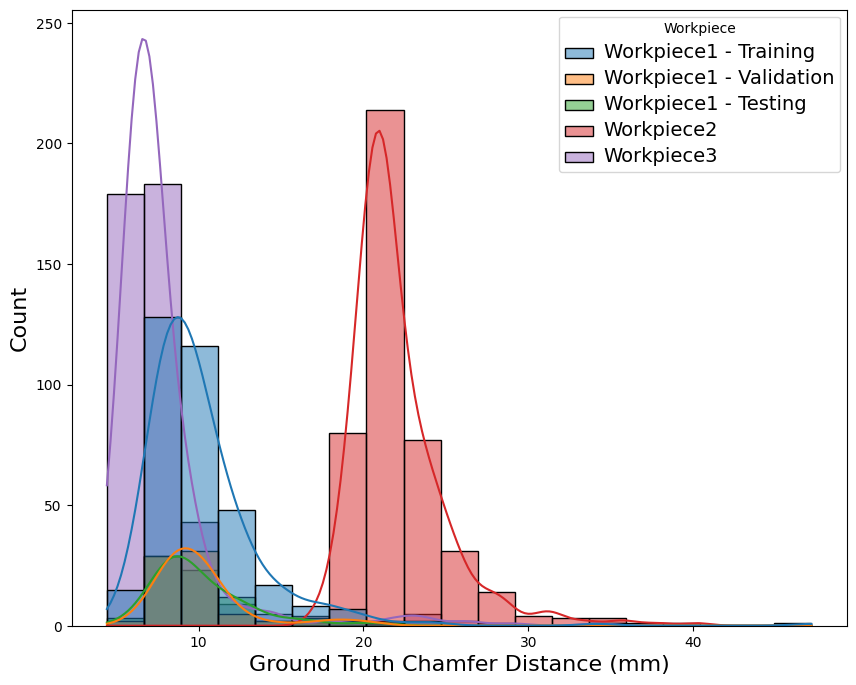

In [64]:
fig1, ax1 = plt.subplots(figsize=(10, 8))
sns.histplot(data=df, x='GroundTruth_CD', hue='Workpiece', kde=True, ax=ax1)
plt.setp(ax1.get_legend().get_texts(), fontsize='16') 
plt.setp(ax1.get_legend().get_texts(), fontsize='14') 
ax1.set_xlabel('Ground Truth Chamfer Distance (mm)', fontsize=16)
ax1.set_ylabel('Count', fontsize=16)

plt.show()